# **1. 손 글씨 숫자 데이터셋**
손글씨 숫자 데이터셋은 0부터 9까지의 숫자를 손글씨로 쓴 흑백 이미지로 구성되어 있으며, 
<br>각 이미지는 8x8 픽셀 크기의 64차원 벡터로 표현됩니다. 각 픽셀 값은 0(흰색)에서 16(검은색)까지의 명암값을 가집니다. 
<br>이 데이터는 총 1797개의 샘플로 이루어져 있으며, 각 샘플에는 숫자 클래스(0~9)가 레이블로 붙어 있습니다. 
<br>주로 분류 알고리즘을 학습시키거나 데이터 시각화, 차원 축소 기법 등을 실험하는 데 사용됩니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

In [2]:
digits = load_digits()      # 데이터 증강된 게 아니라 서로 다른 사람이 0~9까지 쓴 글씨가 들어감
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [3]:
X_data = digits['data']     # 훈련
y_data = digits['target']   # 정답

print(X_data.shape)
print(y_data.shape)

(1797, 64)
(1797,)


### ※ axes.flatten() 

axes.flatten()은 다차원 배열 형태로 구성된 Matplotlib의 서브플롯 배열을 1차원 배열로 변환하는 메서드입니다. 
<br>Matplotlib에서 다수의 서브플롯을 생성할 때, plt.subplots()는 2차원 배열 형태로 서브플롯 객체를 반환합니다. 
<br>이 배열은 각 서브플롯을 접근하기 위해 행과 열의 인덱스를 사용해야 하지만, flatten() 메서드를 사용하면 이 배열을 1차원으로 펼쳐서 각 서브플롯을 단일 인덱스로 순회할 수 있게 됩니다.

### 내 설명
평활화가 아니라 평탄화 작업
<br>즉, 다차원 배열에서 1차원 배열로 만드는 함수

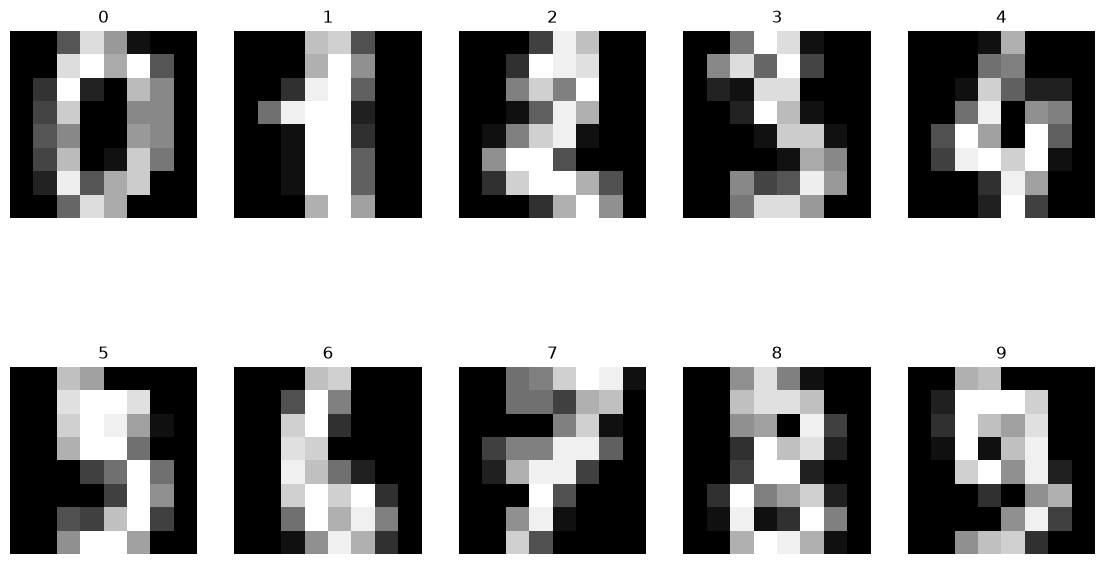

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 8))     # 2랑 5에서 숫자 더 키우면 다양한 데이터셋 볼 수 있음

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_data[i].reshape((8, 8)), cmap='gray') # 크기가 8x8임 
    ax.set_title(y_data[i])
    ax.axis('off')

In [5]:
X_data = torch.FloatTensor(X_data)
y_data = torch.LongTensor(y_data)

print(X_data.shape)
print(y_data.shape)

torch.Size([1797, 64])
torch.Size([1797])


In [6]:
x_train, x_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)  # train은 80% test는 20%로 test_size 0.2가

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([360, 64]) torch.Size([360])


# **2. 데이터 로더**
데이터로더(Data Loader)는 데이터셋을 효율적으로 관리하고, 모델 학습 과정에서 데이터를 쉽게 가져올 수 있도록 도와주는 도구입니다. 
<br>일반적으로 데이터셋을 배치(batch) 단위로 나누어 모델에 제공하며, 데이터의 크기가 클 경우에도 메모리 효율적으로 처리할 수 있도록 설계되었습니다. 
<br>데이터 증강, 셔플링, 병렬 처리와 같은 기능을 지원하여 학습 성능을 향상시키고, 모델 학습과 평가 시 일관된 데이터 제공 방식을 유지합니다. 
<br>딥러닝 프레임워크에서는 PyTorch의 DataLoader나 TensorFlow의 tf.data 같은 도구를 통해 쉽게 사용할 수 있습니다.

### ※ 데이터로더의 주요 역할

1. 배치 처리: 데이터를 지정된 크기의 배치로 나누어 모델에 제공.  batch_size
2. 셔플링: 데이터 순서를 무작위로 섞어 과적합 방지.   shuffle
3. 병렬 처리: num_workers 옵션을 통해 데이터를 병렬로 로드하여 속도 향상.  num_workers=4  # <--- 바로 여기에 들어갑니다! (보통 본인 PC 코어 수에 맞춰 2~4를 많이 씁니다)
4. 반복 처리: 학습 epoch 동안 데이터를 자동으로 반복해서 제공.  drop_last

In [7]:
loader = DataLoader(
    dataset=list(zip(x_train, y_train)),  # 순서대로 (독립변수, 종속변수)
    batch_size=64,  # 배치 사이즈에서 남은 데이터를 (아래 drop_last)
    shuffle = True, # 데이터 랜덤 섞기
    drop_last=False  # 짜투리 데이터 False는 버림
)

In [8]:
imgs, labels = next(iter(loader))   # iter 순차적 만들어 줌

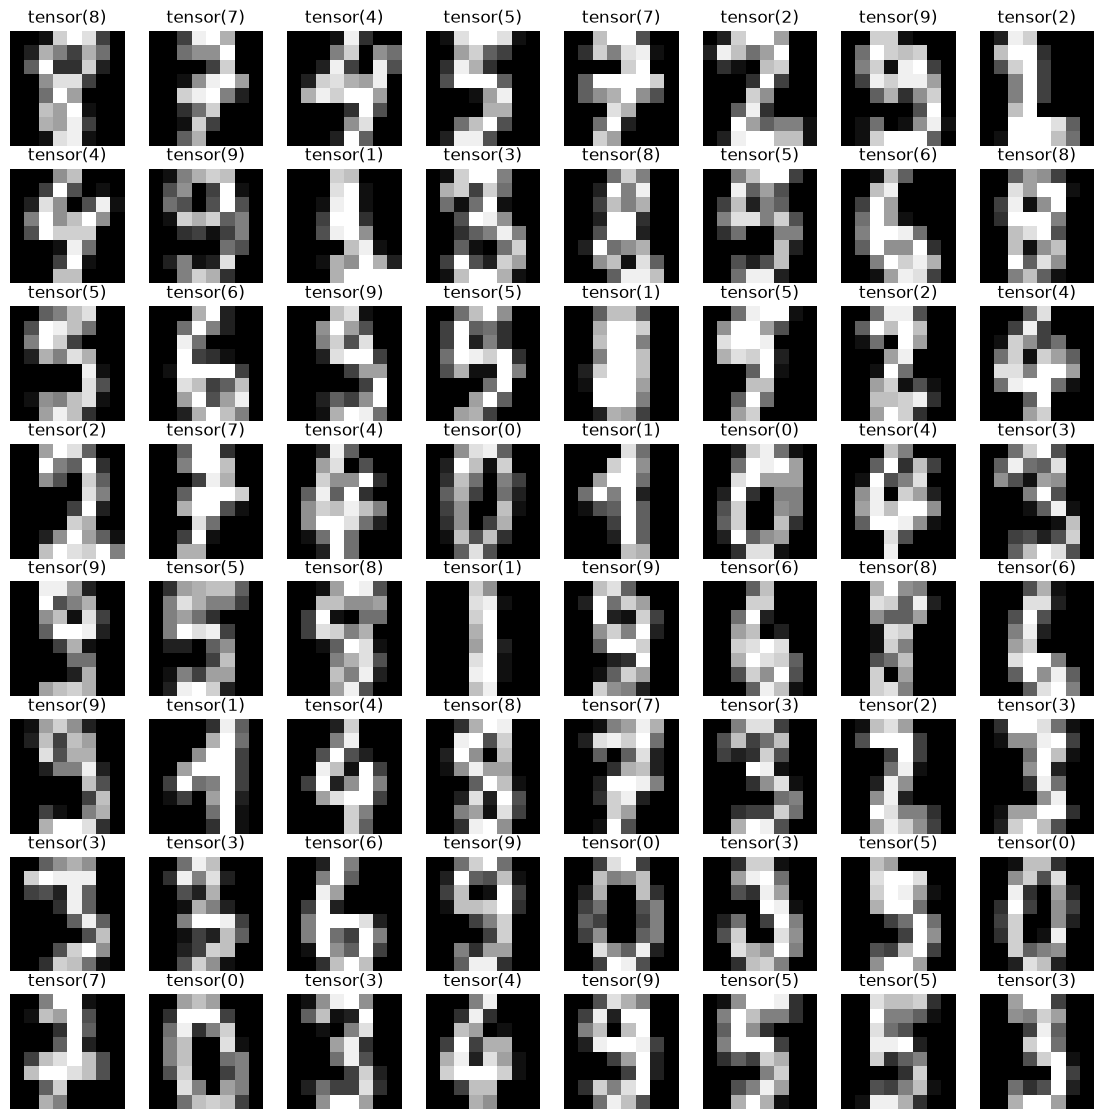

In [9]:
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')

In [10]:
model = nn.Sequential(
    nn.Linear(64, 10)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50

for epoch in range(epochs + 1):
    sum_losses = 0
    sum_accs = 0

    for x_batch, y_batch in loader:
        y_pred = model(x_batch)
        loss = nn.CrossEntropyLoss()(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_losses = sum_losses + loss

        y_prob = nn.Softmax(1)(y_pred)
        y_pred_index = torch.argmax(y_prob, axis=1)
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100
        sum_accs = sum_accs + acc

    avg_loss = sum_losses / len(loader)
    avg_acc = sum_accs / len(loader)
    print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.415013 Accuracy: 64.44%
Epoch    1/50 Loss: 0.252422 Accuracy: 91.67%
Epoch    2/50 Loss: 0.179016 Accuracy: 94.32%
Epoch    3/50 Loss: 0.124470 Accuracy: 95.77%
Epoch    4/50 Loss: 0.096855 Accuracy: 96.66%
Epoch    5/50 Loss: 0.079663 Accuracy: 97.13%
Epoch    6/50 Loss: 0.074169 Accuracy: 98.14%
Epoch    7/50 Loss: 0.060521 Accuracy: 98.71%
Epoch    8/50 Loss: 0.062999 Accuracy: 98.08%
Epoch    9/50 Loss: 0.055629 Accuracy: 98.36%
Epoch   10/50 Loss: 0.055543 Accuracy: 98.36%
Epoch   11/50 Loss: 0.057283 Accuracy: 98.42%
Epoch   12/50 Loss: 0.060953 Accuracy: 97.87%
Epoch   13/50 Loss: 0.057073 Accuracy: 98.10%
Epoch   14/50 Loss: 0.048221 Accuracy: 98.91%
Epoch   15/50 Loss: 0.029713 Accuracy: 99.32%
Epoch   16/50 Loss: 0.026651 Accuracy: 99.52%
Epoch   17/50 Loss: 0.025185 Accuracy: 99.59%
Epoch   18/50 Loss: 0.025557 Accuracy: 99.52%
Epoch   19/50 Loss: 0.024192 Accuracy: 99.52%
Epoch   20/50 Loss: 0.025734 Accuracy: 99.59%
Epoch   21/50 Loss: 0.019491 Accur

tensor(5)


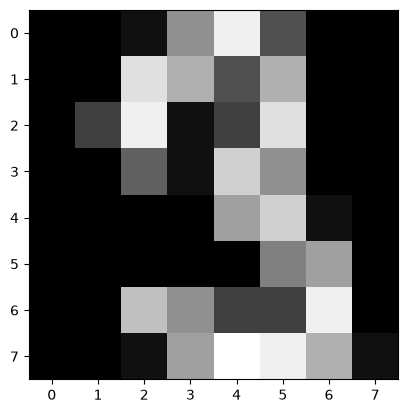

In [29]:
plt.imshow(x_test[10].reshape((8, 8)), cmap='gray')
print(y_test[10])

In [12]:
y_pred = model(x_test)
y_pred[10]

tensor([ -1.0928,  -8.0995,   5.6871,   7.3545, -13.6832,  -5.4515,  -0.8304,
        -10.6973,   3.9758,   8.1677], grad_fn=<SelectBackward0>)

In [13]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[10]

tensor([6.1658e-05, 5.5850e-08, 5.4261e-02, 2.8750e-01, 2.0994e-10, 7.8892e-07,
        8.0164e-05, 4.1574e-09, 9.8014e-03, 6.4829e-01],
       grad_fn=<SelectBackward0>)

In [23]:
for i in range(10):
    print(f'숫자 {i}일 확률: {y_prob[10][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.05
숫자 3일 확률: 0.29
숫자 4일 확률: 0.00
숫자 5일 확률: 0.00
숫자 6일 확률: 0.00
숫자 7일 확률: 0.00
숫자 8일 확률: 0.01
숫자 9일 확률: 0.65


In [24]:
y_pred_index = torch.argmax(y_prob, axis=1)
accuracy = (y_test == y_pred_index).float().sum() / len(y_test) * 100
print(f'테스트 정확도는 {accuracy: .2f}% 입니다.')

테스트 정확도는  95.83% 입니다.


# **3. 데이터 증강**
데이터 증강(Data Augmentation)은 학습 데이터를 인위적으로 변환하여 데이터셋의 다양성을 높이고 모델의 일반화 성능을 향상시키는 기법입니다. 
<br>회전, 크기 조정, 반전, 블러링, 밝기 조정 등 다양한 변환을 적용하여 원본 데이터로부터 새로운 데이터를 생성합니다. 
<br>이를 통해 데이터 부족 문제를 완화하고 모델이 특정 패턴에 과적합되지 않도록 도와줍니다. 
<br>특히, 이미지나 음성 데이터와 같이 특징이 직관적인 데이터에서 효과적으로 활용되며, 
<br>증강된 데이터는 모델이 예측 대상의 다양한 변형에 대해 강하게 학습할 수 있도록 돕습니다.

In [30]:
from torchvision import transforms
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([360, 64]) torch.Size([360])


### ※ transforms.Compose

여러 데이터 변환(transform) 작업을 순차적으로 적용할 수 있도록 해줍니다. 이미지 데이터 전처리와 증강 과정에서 자주 사용되며, 각 변환을 하나의 리스트로 묶어 실행합니다.

1. transforms.RandomRotation(10)
- 기능: 이미지를 -10도에서 +10도 사이로 무작위 회전시킵니다.
    - 10은 회전 범위를 나타냅니다.
    - 각 호출 시, -10도 ~ +10도 범위에서 무작위로 각도를 선택하여 이미지를 회전합니다.

2. transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1))
- 기능: 이미지를 비틀기(shear), 크기 조정(scale) 등의 변환을 수행합니다.
    - 0: 회전(각도) 변환을 수행하지 않음을 의미합니다.
    - shear=5: 이미지를 최대 5도만큼 비스듬하게 비틀기(shear) 변환을 수행합니다.
        - 예: 정사각형이 평행사변형처럼 기울어질 수 있습니다.
    - scale=(0.9, 1.1):
        - 이미지를 0.9배(축소)에서 1.1배(확대) 범위 내에서 무작위 크기 조정을 수행합니다.
        - 각 호출 시, 무작위로 크기가 변경됩니다.

In [36]:
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1)),
])

In [37]:
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = x.view(8, 8).unsqueeze(0)  # 8x8 이미지를 1채널로 변환  # unsqueeze(0)은 인덱스 0번에 1을 추가함 (8,8) -> (1, 8, 8), 1이면 8,1,8이 됨
        x = self.transform(x)  # 증강 적용
        return x.flatten(), y  # 다시 Flatten


augmented_train_dataset = AugmentedDataset(train_dataset, transform)

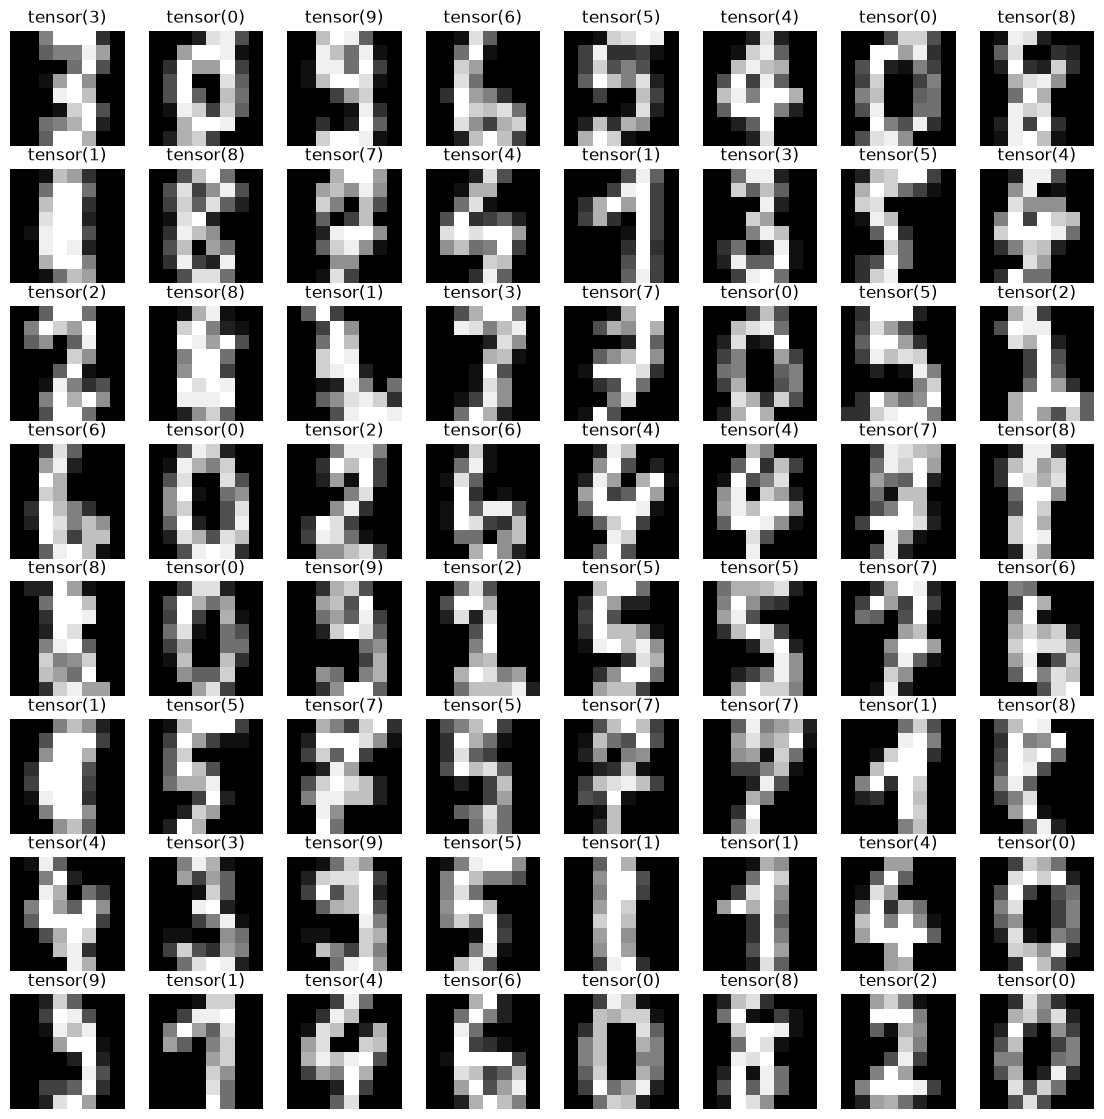

In [38]:
train_loader = DataLoader(augmented_train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')

In [39]:
for images, labels in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    break

Image batch shape: torch.Size([64, 64])
Label batch shape: torch.Size([64])


In [40]:
model = nn.Sequential(
    nn.Linear(64, 10)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50
for epoch in range(epochs + 1):
    sum_losses = 0
    sum_accs = 0

    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = nn.CrossEntropyLoss()(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_losses = sum_losses + loss

        y_prob = nn.Softmax(1)(y_pred)
        y_pred_index = torch.argmax(y_prob, axis=1)
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100
        sum_accs = sum_accs + acc

    if epoch % 10 == 0:
        avg_loss = sum_losses / len(loader)
        avg_acc = sum_accs / len(loader)
        print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.755652 Accuracy: 60.91%
Epoch   10/50 Loss: 0.065311 Accuracy: 97.95%
Epoch   20/50 Loss: 0.044417 Accuracy: 98.85%
Epoch   30/50 Loss: 0.032550 Accuracy: 99.25%
Epoch   40/50 Loss: 0.032847 Accuracy: 98.91%
Epoch   50/50 Loss: 0.038127 Accuracy: 98.51%


tensor(5)


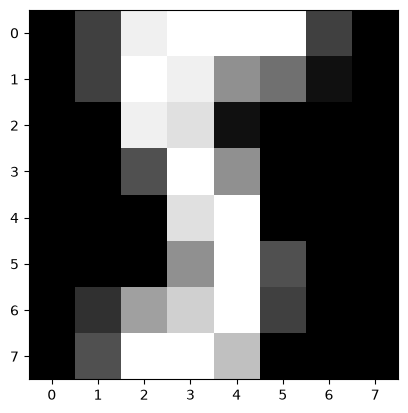

In [47]:
plt.imshow(x_test[11].reshape((8, 8)), cmap='gray')
print(y_test[11])

In [43]:
y_pred = model(x_test)
y_pred[11]

tensor([-21.2770,  -3.6728,  -2.5916,   4.2799, -17.4170,  17.2327, -27.2580,
         -4.6095,   4.8970,  -2.2813], grad_fn=<SelectBackward0>)

In [44]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[11]

tensor([1.8856e-17, 8.3340e-10, 2.4569e-09, 2.3695e-06, 8.9493e-16, 9.9999e-01,
        4.7636e-20, 3.2660e-10, 4.3917e-06, 3.3510e-09],
       grad_fn=<SelectBackward0>)

In [45]:
for i in range(10):
    print(f'숫자 {i}일 확률: {y_prob[11][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.00
숫자 3일 확률: 0.00
숫자 4일 확률: 0.00
숫자 5일 확률: 1.00
숫자 6일 확률: 0.00
숫자 7일 확률: 0.00
숫자 8일 확률: 0.00
숫자 9일 확률: 0.00
